# Sinusoidal plus Residual (SPR) Model Example

Demonstrates the **SPR Model**, which separates a sound into a sinusoidal component and a residual component:
1. Load audio and inspect the waveform
2. Analyse with the SPR model, resynthesize, and inspect all three components (full output, sinusoids, residual)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from scipy.signal import get_window
from smstools.models import utilFunctions as UF
from smstools.models import sprModel as SPR
from smstools.models import stft as STFT
from smstools.models import dftModel as DFT
import plot_helpers as PH

PH.setup_plot_style()

## 1) Load audio and inspect waveform

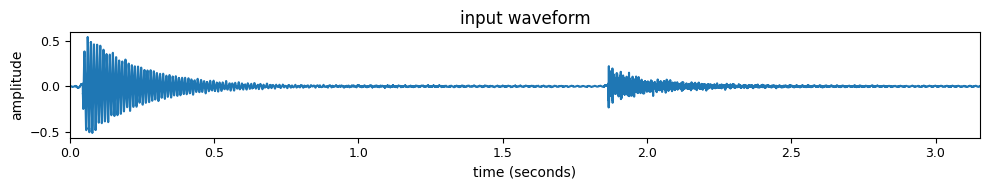

In [2]:
input_file = '../sounds/bendir.wav'
fs, x = UF.wavread(input_file)

fig, ax = plt.subplots(figsize=(10, 2))
PH.plot_waveform(ax, x, fs, title='input waveform', xlabel='time (seconds)')
plt.tight_layout()
plt.show()

ipd.display(ipd.Audio(data=x, rate=fs))

## 2) SPR model analysis and synthesis

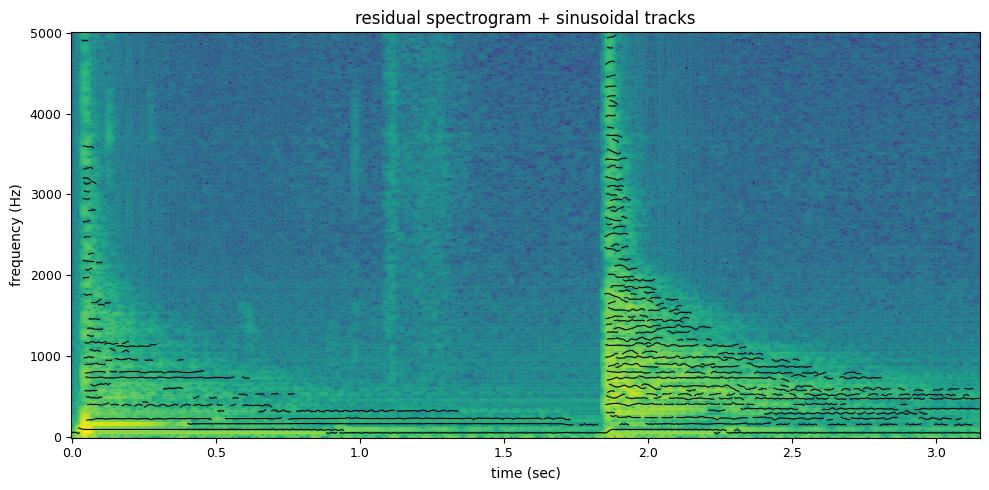

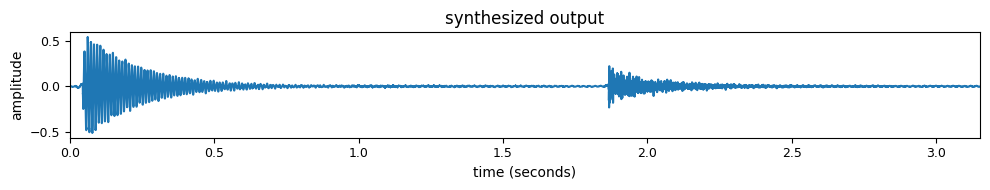

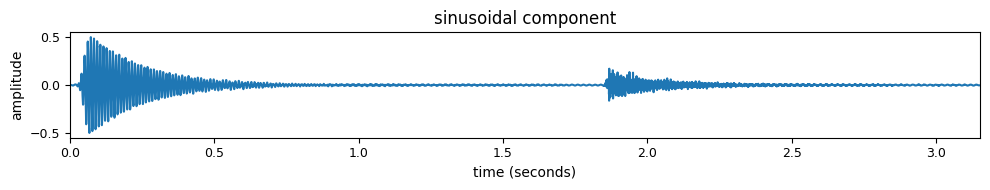

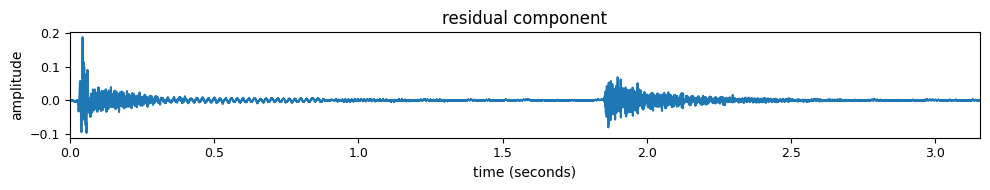

In [3]:
# analysis / synthesis parameters
window = 'hamming'
M = 2001
N = 2048
t = -80
min_sine_dur = 0.02
max_n_sines = 150
freq_dev_offset = 10
freq_dev_slope = 0.001
Ns = 512    # FFT size for synthesis
H = 128     # hop size (must be Ns/4)
max_plot_freq = 5000.0

w = get_window(window, M)
tfreq, tmag, tphase, xr = SPR.sprModelAnal(
    x, fs, w, N, H, t, min_sine_dur, max_n_sines,
    freq_dev_offset, freq_dev_slope
)
mXr, _ = STFT.stftAnal(xr, w, N, H)
y, ys = SPR.sprModelSynth(tfreq, tmag, tphase, xr, Ns, H, fs)

# --- residual spectrogram with sinusoidal tracks overlay ---
fig, ax = plt.subplots(figsize=(10, 5))
PH.plot_spectrogram_with_tracks(ax, mXr, tfreq, fs, N, H, max_plot_freq=max_plot_freq, title='residual spectrogram + sinusoidal tracks')
plt.tight_layout()
plt.show()

# --- full synthesized output ---
fig2, ax2 = plt.subplots(figsize=(10, 2))
PH.plot_waveform(ax2, y, fs, title='synthesized output', xlabel='time (seconds)')
plt.tight_layout()
plt.show()
ipd.display(ipd.Audio(data=y, rate=fs))

# --- sinusoidal component ---
fig3, ax3 = plt.subplots(figsize=(10, 2))
PH.plot_waveform(ax3, ys, fs, title='sinusoidal component', xlabel='time (seconds)')
plt.tight_layout()
plt.show()
ipd.display(ipd.Audio(data=ys, rate=fs))

# --- residual component ---
fig4, ax4 = plt.subplots(figsize=(10, 2))
PH.plot_waveform(ax4, xr, fs, title='residual component', xlabel='time (seconds)')
plt.tight_layout()
plt.show()
ipd.display(ipd.Audio(data=xr, rate=fs))

## 3) Compare original, sinusoidal, and residual waveforms

This section displays a short segment of the original sound, superposed with the sinusoidal and residual waveforms for direct visual comparison.

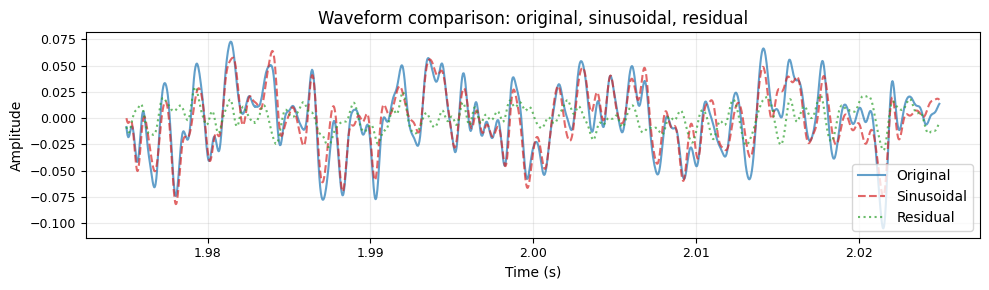

In [4]:
# Compare original, sinusoidal, and residual waveforms for a short section
section_time = 2.0  # seconds (center of the section)
section_dur = 0.05  # duration in seconds
center = int(section_time * fs)
half_len = int(section_dur * fs / 2)
start = max(center - half_len, 0)
end = min(center + half_len, len(x))

time_axis = np.arange(start, end) / fs
x_section = x[start:end]
ys_section = ys[start:end]
xr_section = xr[start:end]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time_axis, x_section, label='Original', color='tab:blue', alpha=0.7)
ax.plot(time_axis, ys_section, label='Sinusoidal', color='tab:red', linestyle='--', alpha=0.7)
ax.plot(time_axis, xr_section, label='Residual', color='tab:green', linestyle=':', alpha=0.7)
ax.set_title('Waveform comparison: original, sinusoidal, residual')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()